In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("COVID_Parcel_Business.csv")
df.head()

,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
0,718117,2021,1,8
1,718117,2020,7,257
2,718117,2019,39,141
3,718117,2018,1,14
4,718117,2021,2,192


In [4]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isna().sum())

(190719, 4)
Index(['FakeCustomerID', 'THE_YEAR', 'THE_WEEK', 'VOLUME'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190719 entries, 0 to 190718
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   FakeCustomerID  190719 non-null  int64
 1   THE_YEAR        190719 non-null  int64
 2   THE_WEEK        190719 non-null  int64
 3   VOLUME          190719 non-null  int64
dtypes: int64(4)
memory usage: 5.8 MB
None
       FakeCustomerID       THE_YEAR       THE_WEEK         VOLUME
count   190719.000000  190719.000000  190719.000000  190719.000000
mean    541440.234963    2019.395220      25.676377    1174.911519
std     264861.365663       1.068845      14.722539   11586.730666
min     100771.000000    2018.000000       1.000000       1.000000
25%     308930.000000    2018.000000      13.000000      25.000000
50%     529707.000000    2019.000000      25.000000      58.000000
75%     778800.000000    2

In [5]:
df.columns = ["CustomerID", "Year", "Week", "Volume"]
df.head()

,CustomerID,Year,Week,Volume
0,718117,2021,1,8
1,718117,2020,7,257
2,718117,2019,39,141
3,718117,2018,1,14
4,718117,2021,2,192


In [6]:
yearly = df.groupby("Year")["Volume"].sum().reset_index()
yearly

,Year,Volume
0,2018,49099478
1,2019,52823114
2,2020,73475690
3,2021,48679668


In [7]:
yearly = df.groupby("Year")["Volume"].sum().reset_index()
yearly

,Year,Volume
0,2018,49099478
1,2019,52823114
2,2020,73475690
3,2021,48679668


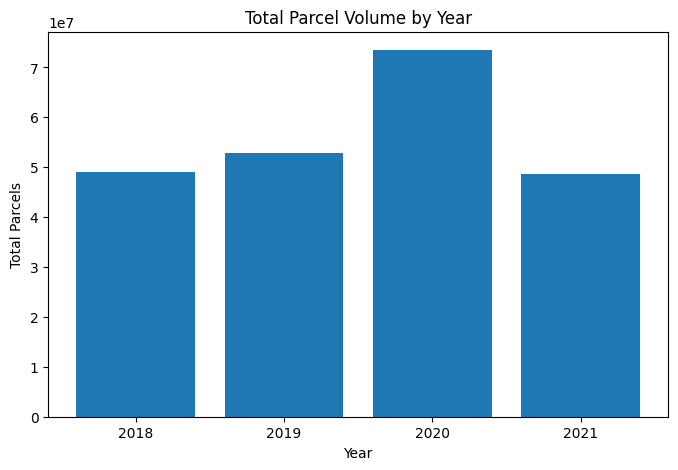

In [8]:
plt.figure(figsize=(8,5))
plt.bar(yearly["Year"].astype(str), yearly["Volume"])
plt.title("Total Parcel Volume by Year")
plt.xlabel("Year")
plt.ylabel("Total Parcels")
plt.show()

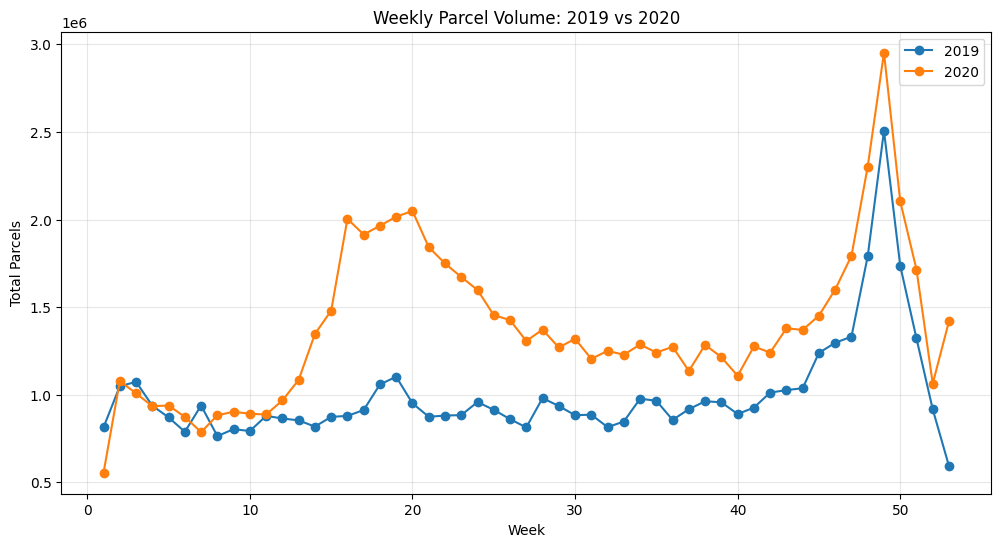

In [9]:
weekly = df.groupby(["Year", "Week"], as_index=False)["Volume"].sum()

plt.figure(figsize=(12,6))
for yr in [2019, 2020]:
    temp = weekly[weekly["Year"] == yr]
    plt.plot(temp["Week"], temp["Volume"], marker='o', label=str(yr))

plt.title("Weekly Parcel Volume: 2019 vs 2020")
plt.xlabel("Week")
plt.ylabel("Total Parcels")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
pre_2019 = df[(df["Year"] == 2019) & (df["Week"].between(1,15))]["Volume"].sum()
pre_2020 = df[(df["Year"] == 2020) & (df["Week"].between(1,15))]["Volume"].sum()

isgr = (pre_2020 - pre_2019) / pre_2019

print("Pre-COVID 2019:", pre_2019)
print("Pre-COVID 2020:", pre_2020)
print("ISGR:", isgr)
print("ISGR %:", round(isgr*100, 2), "%")

Pre-COVID 2019: 13122816
Pre-COVID 2020: 14619017
ISGR: 0.11401523880240338
ISGR %: 11.4 %


In [11]:
covid_2019 = df[(df["Year"] == 2019) & (df["Week"].between(16,53))]["Volume"].sum()
covid_2020 = df[(df["Year"] == 2020) & (df["Week"].between(16,53))]["Volume"].sum()

covid_growth = (covid_2020 - covid_2019) / covid_2019

print("2019 baseline for COVID period:", covid_2019)
print("2020 COVID period:", covid_2020)
print("COVID period growth %:", round(covid_growth*100, 2))

2019 baseline for COVID period: 39700298
2020 COVID period: 58856673
COVID period growth %: 48.25


In [12]:
pivot = weekly.pivot(index="Week", columns="Year", values="Volume")
pivot["Diff"] = pivot[2020] - pivot[2019]
pivot["Pct_Diff"] = pivot["Diff"] / pivot[2019]

pivot.loc[1:20]

Year,2018,2019,2020,2021,Diff,Pct_Diff
Week,,,,,,
1,817751.0,814361.0,554951.0,134137.0,-259410.0,-0.318544
2,925839.0,1048800.0,1078417.0,1583754.0,29617.0,0.028239
3,854760.0,1073634.0,1008084.0,1322546.0,-65550.0,-0.061054
4,800040.0,937502.0,934713.0,1310292.0,-2789.0,-0.002975
5,812249.0,870849.0,938521.0,1270718.0,67672.0,0.077708
6,816852.0,788670.0,873763.0,1207747.0,85093.0,0.107894
7,745839.0,938386.0,786626.0,1045947.0,-151760.0,-0.161724
8,662325.0,764078.0,882633.0,1042340.0,118555.0,0.155161
9,841255.0,803745.0,903362.0,1153193.0,99617.0,0.123941


In [13]:
peak_2019_20 = df[((df["Year"] == 2019) & (df["Week"] >= 45)) | ((df["Year"] == 2020) & (df["Week"] <= 3))]["Volume"].sum()
peak_2020_21 = df[((df["Year"] == 2020) & (df["Week"] >= 45)) | ((df["Year"] == 2021) & (df["Week"] <= 3))]["Volume"].sum()

peak_growth = (peak_2020_21 - peak_2019_20) / peak_2019_20

print("Peak 2019-20:", peak_2019_20)
print("Peak 2020-21:", peak_2020_21)
print("Peak growth %:", round(peak_growth*100, 2))

Peak 2019-20: 15372691
Peak 2020-21: 19442907
Peak growth %: 26.48


In [14]:
customers = pd.DataFrame({"CustomerID": sorted(df["CustomerID"].unique())}).set_index("CustomerID")

customers["vol_2019_all"] = df[df["Year"] == 2019].groupby("CustomerID")["Volume"].sum()
customers["vol_pre2020"] = df[(df["Year"] == 2020) & (df["Week"].between(1,15))].groupby("CustomerID")["Volume"].sum()
customers["vol_covid2019_base"] = df[(df["Year"] == 2019) & (df["Week"].between(16,53))].groupby("CustomerID")["Volume"].sum()
customers["vol_covid2020"] = df[(df["Year"] == 2020) & (df["Week"].between(16,53))].groupby("CustomerID")["Volume"].sum()

customers = customers.fillna(0)

In [15]:
isgr = (pre_2020 - pre_2019) / pre_2019

customers["new_customer"] = ((customers["vol_2019_all"] + customers["vol_pre2020"]) == 0) & (customers["vol_covid2020"] > 0)
customers["lost_customer"] = ((customers["vol_2019_all"] + customers["vol_pre2020"]) > 0) & (customers["vol_covid2020"] == 0)

customers["growth_rate_covid"] = np.where(
    customers["vol_covid2019_base"] > 0,
    (customers["vol_covid2020"] - customers["vol_covid2019_base"]) / customers["vol_covid2019_base"],
    np.nan
)

conditions = [
    customers["new_customer"],
    customers["lost_customer"],
    (~customers["new_customer"]) & (~customers["lost_customer"]) & (customers["growth_rate_covid"] < 0),
    (~customers["new_customer"]) & (~customers["lost_customer"]) & (customers["growth_rate_covid"] >= 0) & (customers["growth_rate_covid"] <= isgr),
    (~customers["new_customer"]) & (~customers["lost_customer"]) & (customers["growth_rate_covid"] > isgr)
]

choices = ["New", "Lost", "Declining", "Stable", "High Growth"]

customers["status"] = np.select(conditions, choices, default="Unclassified")

customers["status"].value_counts()

,count
status,
High Growth,597
Declining,359
Stable,75
Lost,30


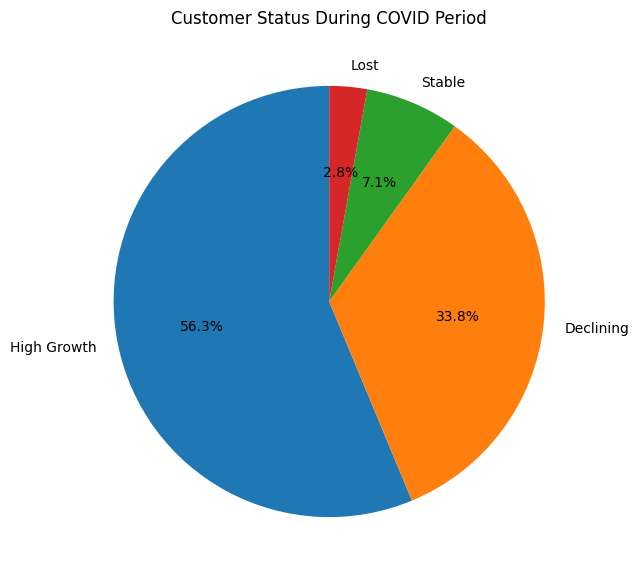

In [16]:
status_counts = customers["status"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Status During COVID Period")
plt.show()

In [17]:
customers["vol2019"] = customers["vol_2019_all"]

q50 = customers["vol2019"].quantile(0.50)
q75 = customers["vol2019"].quantile(0.75)
q95 = customers["vol2019"].quantile(0.95)

def assign_group(v):
    if v >= q95:
        return "Enterprise"
    elif v >= q75:
        return "Large"
    elif v >= q50:
        return "Medium"
    else:
        return "Small"

customers["customer_group"] = customers["vol2019"].apply(assign_group)
customers["customer_group"].value_counts()

,count
customer_group,
Small,530
Medium,265
Large,212
Enterprise,54


In [18]:
customers["vol2020"] = df[df["Year"] == 2020].groupby("CustomerID")["Volume"].sum()
customers["vol2020"] = customers["vol2020"].fillna(0)

customers["gross_rev_2019"] = customers["vol2019"] * 22
customers["gross_rev_2020"] = customers["vol2020"] * 22

group_summary = customers.groupby("customer_group").agg(
    customers=("customer_group", "size"),
    vol_2019=("vol2019", "sum"),
    vol_2020=("vol2020", "sum"),
    rev_2019=("gross_rev_2019", "sum"),
    rev_2020=("gross_rev_2020", "sum")
).reset_index()

group_summary["vol_growth_pct"] = (group_summary["vol_2020"] - group_summary["vol_2019"]) / group_summary["vol_2019"]
group_summary["rev_growth_pct"] = (group_summary["rev_2020"] - group_summary["rev_2019"]) / group_summary["rev_2019"]

group_summary

,customer_group,customers,vol_2019,vol_2020,rev_2019,rev_2020,vol_growth_pct,rev_growth_pct
0,Enterprise,54,46491589,64178538.0,1022814958,1.411928e+09,0.380433,0.380433
1,Large,212,4191330,5954800.0,92209260,1.310056e+08,0.420742,0.420742
2,Medium,265,1216563,1793124.0,26764386,3.944873e+07,0.473926,0.473926
3,Small,530,923632,1549228.0,20319904,3.408302e+07,0.677322,0.677322


In [19]:
counts = customers.groupby(["customer_group", "status"]).size().unstack(fill_value=0)
status_pct = counts.div(counts.sum(axis=1), axis=0) * 100

print(status_pct.round(1))

status          Declining  High Growth  Lost  Stable
customer_group                                      
Enterprise           24.1         63.0   0.0    13.0
Large                36.3         52.8   2.4     8.5
Medium               34.3         57.7   3.4     4.5
Small                33.6         56.2   3.0     7.2


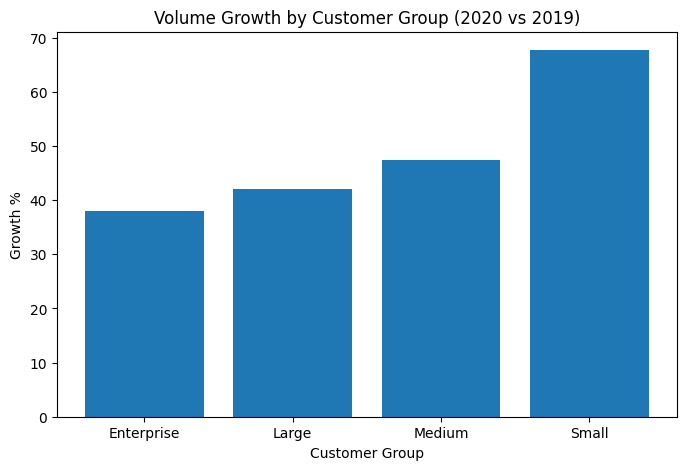

In [20]:
plt.figure(figsize=(8,5))
plt.bar(group_summary["customer_group"], group_summary["vol_growth_pct"] * 100)
plt.title("Volume Growth by Customer Group (2020 vs 2019)")
plt.xlabel("Customer Group")
plt.ylabel("Growth %")
plt.show()